## End-to-End-ML-Project 13/100 days of ML

In [1]:
import pandas as pd

In [20]:
df = pd.read_csv("placement.csv")

In [3]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [5]:
df.shape

(100, 4)

### So this is the placement data, and there are 100 rows , 4 columsn. we need to remove the unnamed col , and here are the steps for project end to end

#### preprocess + EDA + feature selection (we are using logistical regression)
#### separate input and output columns
#### split up training and testing dataset
#### train the model using sklearn
#### evaluate/test model
#### deploy

In [10]:
df = df.iloc

In [24]:
import matplotlib.pyplot as plt

In [17]:
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [21]:
df = df.iloc[:,1:]

In [22]:
df


,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


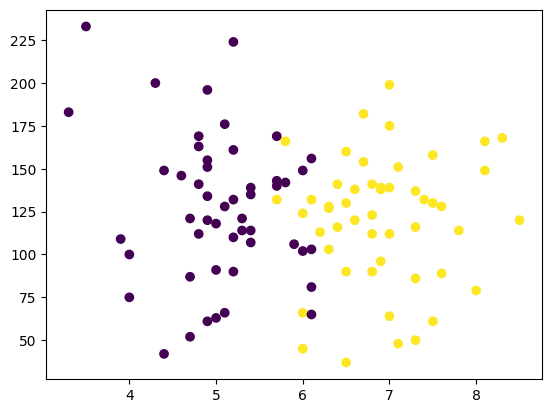

In [25]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [27]:
x = df.iloc[:,0:2]

In [28]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [31]:
y = df.iloc[:,-1]

In [32]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

## Splitting values into Training-Set and Testing-Set

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [51]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size = 0.1)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [52]:
x_train

array([[ 0.06222693,  0.87848225],
       [ 0.95118314,  0.75038212],
       [-1.09341613, -0.24879893],
       [-1.27120737,  0.62228198],
       [ 0.50670504, -0.04383871],
       [ 0.41780942, -0.81243952],
       [-0.73783365, -0.30003898],
       [ 1.39566124, -0.83805954],
       [ 1.30676562, -1.5554203 ],
       [-1.00452051,  0.75038212],
       [ 0.50670504,  0.41732177],
       [ 0.7733919 ,  0.41732177],
       [-1.44899861, -2.04220081],
       [ 0.86228752,  1.98014341],
       [ 1.39566124,  0.1611215 ],
       [-0.02666869,  0.69914207],
       [-0.29335555,  0.46856182],
       [-1.09341613,  0.49418185],
       [ 2.19572182, -0.04383871],
       [ 1.12897438,  0.39170174],
       [ 1.12897438, -1.83724059],
       [ 0.06222693, -1.45294019],
       [ 0.06222693,  0.26360161],
       [-1.00452051, -1.5554203 ],
       [ 2.01793058,  1.18592258],
       [-1.80458109, -0.55623925],
       [-0.82672927, -1.42732016],
       [-1.18231175, -1.78600054],
       [-0.20445993,

x_test

In [55]:
from sklearn.linear_model import LogisticRegression

In [57]:
clf = LogisticRegression()

## Model Training

In [59]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluate Model

In [61]:
clf.predict(x_test)

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 1], dtype=int64)

In [63]:
y_test

46    0
17    0
76    0
14    0
84    0
22    0
16    0
58    1
74    1
98    1
Name: placement, dtype: int64

In [66]:
from sklearn.metrics import accuracy_score
y_pred = clf.predict(x_test)

In [67]:
accuracy_score(y_test,y_pred)

0.9

In [70]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

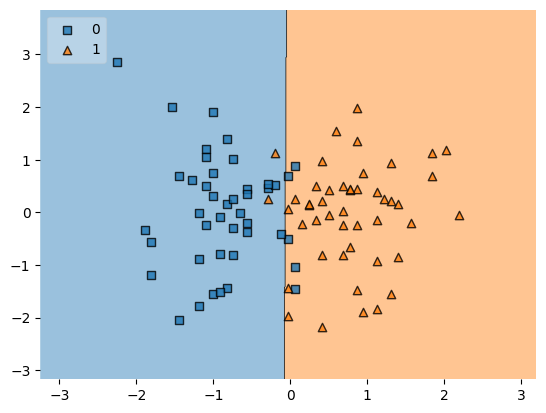

In [72]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [73]:
import pickle

In [74]:
pickle.dump(clf,open('model.pkl','wb'))

 cd /c/Users/KIIT/End-to-EndProject-100DAYML